In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing,

In [ ]:
import pandas as pd

df1 = pd.read_csv('test.csv')
df2 = pd.read_csv('train.csv')
df3 = pd.read_csv('validation.csv')

merged_df = pd.concat([df1, df2, df3], ignore_index=True)

print(merged_df.head())

merged_df.to_csv('merged_data.csv', index=False)

   flow_duration  Header_Length  Protocol Type  Duration          Rate  \
0       5.018181         125.82           6.00     64.00      0.471037   
1       0.000000           0.00          47.00     64.00      4.992473   
2       0.000000          55.22           6.05     65.27     31.735421   
3       0.008299        5213.00          17.00     64.00  19365.300906   
4       4.672666         108.00           6.00     64.00      0.428021   

          Srate  Drate  fin_flag_number  syn_flag_number  rst_flag_number  \
0      0.471037    0.0              0.0              1.0              0.0   
1      4.992473    0.0              0.0              0.0              0.0   
2     31.735421    0.0              0.0              0.0              0.0   
3  19365.300906    0.0              0.0              0.0              0.0   
4      0.428021    0.0              0.0              0.0              0.0   

   ...      Std  Tot size           IAT  Number   Magnitue    Radius  \
0  ...  0.00000     

In [ ]:


df = pd.read_csv('merged_data.csv')

unique_count = df['label'].nunique()
print("Number of unique entries in 'label':", unique_count)

unique_values = df['label'].unique()
print("\nUnique labels:", unique_values)

label_counts = df['label'].value_counts()
print("\nLabel counts:\n", label_counts)

Number of unique entries in 'label': 35

Unique labels: ['DDoS-SynonymousIP_Flood' 'Mirai-greeth_flood' 'DDoS-TCP_Flood'
 'DDoS-UDP_Flood' 'DoS-TCP_Flood' 'DoS-HTTP_Flood' 'DDoS-PSHACK_Flood'
 'DDoS-RSTFINFlood' 'DDoS-ICMP_Flood' 'DoS-UDP_Flood' 'DDoS-SYN_Flood'
 'Mirai-greip_flood' 'Mirai-udpplain' 'DoS-SYN_Flood'
 'DDoS-ACK_Fragmentation' 'DictionaryBruteForce' 'DNS_Spoofing'
 'BenignTraffic' 'Recon-HostDiscovery' 'DDoS-ICMP_Fragmentation'
 'Recon-PortScan' 'DDoS-UDP_Fragmentation' 'MITM-ArpSpoofing'
 'DDoS-HTTP_Flood' 'VulnerabilityScan' 'Recon-OSScan' 'XSS'
 'Uploading_Attack' 'BrowserHijacking' 'DDoS-SlowLoris' 'SqlInjection'
 'Backdoor_Malware' 'CommandInjection' 'Recon-PingSweep' 'DDoS-Syn' nan]

Label counts:
 label
DDoS-ICMP_Flood            23432
DDoS-UDP_Flood             17367
DDoS-TCP_Flood             14141
DDoS-PSHACK_Flood          12998
DDoS-SYN_Flood             12828
DDoS-RSTFINFlood           12807
DDoS-SynonymousIP_Flood    11454
DoS-UDP_Flood              10491
Do

In [ ]:

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import gc, os

# Load your merged dataset
csv_path = "merged_data.csv"   # ✅ fixed

print(f"Loading {csv_path} ...")

df = pd.read_csv(csv_path)

print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading merged_data.csv ...
Loaded dataset: 148,969 rows × 47 columns


In [ ]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f" After cleaning: {df.shape[0]:,} rows")

 After cleaning: 148,967 rows


In [ ]:

target_classes = [
    "BenignTraffic",
    "DDoS-ICMP_Flood",
    "DDoS-UDP_Flood",
    "DDoS-TCP_Flood",
    "DDoS-PSHACK_Flood",
    "DDoS-SYN_Flood",
    "DDoS-RSTFINFlood",
    "DDoS-SynonymousIP_Flood"
]

df = df[df["label"].isin(target_classes)]
print(f" Filtered to 8 target classes: {df['label'].nunique()} unique labels")

 Filtered to 8 target classes: 8 unique labels


In [ ]:
# ---------------------------------------------------------------
#   Downsample each class to 184,766 samples
# ---------------------------------------------------------------
samples_per_class = 184_766
balanced_df = []

for label, group in df.groupby("label"):
    if len(group) >= samples_per_class:
        sampled = group.sample(n=samples_per_class, random_state=42)
    else:
        sampled = group.sample(n=samples_per_class, replace=True, random_state=42)
    balanced_df.append(sampled)
    print(f"Class {label:25s} → {len(sampled)} samples")

df_bal = pd.concat(balanced_df, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\n Balanced dataset shape: {df_bal.shape}")


Class BenignTraffic             → 184766 samples
Class DDoS-ICMP_Flood           → 184766 samples
Class DDoS-PSHACK_Flood         → 184766 samples
Class DDoS-RSTFINFlood          → 184766 samples
Class DDoS-SYN_Flood            → 184766 samples
Class DDoS-SynonymousIP_Flood   → 184766 samples
Class DDoS-TCP_Flood            → 184766 samples
Class DDoS-UDP_Flood            → 184766 samples

 Balanced dataset shape: (1478128, 47)


In [ ]:
# ---------------------------------------------------------------
#   Encode labels (0–7)
# ---------------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(df_bal["label"])
print("\nLabel mapping:")
for i, cls in enumerate(le.classes_):
    print(f"{i} → {cls}")

X = df_bal.drop(columns=["label"])
del df_bal
gc.collect()



Label mapping:
0 → BenignTraffic
1 → DDoS-ICMP_Flood
2 → DDoS-PSHACK_Flood
3 → DDoS-RSTFINFlood
4 → DDoS-SYN_Flood
5 → DDoS-SynonymousIP_Flood
6 → DDoS-TCP_Flood
7 → DDoS-UDP_Flood


0

In [ ]:
# ---------------------------------------------------------------
#   Convert to numeric (handle non-numerical if any)
# ---------------------------------------------------------------
non_num = X.select_dtypes(exclude=[np.number]).columns
if len(non_num) > 0:
    print("Encoding non-numeric columns:", list(non_num))
    for c in non_num:
        X[c] = pd.factorize(X[c])[0]

X = X.astype(np.float32)
print(f" Final feature matrix: {X.shape}")

 Final feature matrix: (1478128, 46)


In [ ]:
# ---------------------------------------------------------------
#   Train/Test split (70–30 stratified)
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print(f" Train: {X_train.shape}, Test: {X_test.shape}")

 Train: (1034689, 46), Test: (443439, 46)


In [ ]:
import os
import numpy as np

os.makedirs("/content", exist_ok=True)

np.save("/content/X_train_multi.npy", X_train)
np.save("/content/X_test_multi.npy", X_test)
np.save("/content/y_train_multi.npy", y_train)
np.save("/content/y_test_multi.npy", y_test)

print("\n Phase 1 complete — Multi-Class data ready for PCA:")
print("   /content/X_train_multi.npy")
print("   /content/X_test_multi.npy")
print("   /content/y_train_multi.npy")
print("   /content/y_test_multi.npy")


 Phase 1 complete — Multi-Class data ready for PCA:
   /content/X_train_multi.npy
   /content/X_test_multi.npy
   /content/y_train_multi.npy
   /content/y_test_multi.npy


In [ ]:

#  PHASE 2 — PCA
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import os

In [ ]:
X_train = np.load("/content/X_train_multi.npy")
X_test  = np.load("/content/X_test_multi.npy")
y_train = np.load("/content/y_train_multi.npy")
y_test  = np.load("/content/y_test_multi.npy")
print(f"Loaded data: X_train={X_train.shape}, X_test={X_test.shape}, Classes={len(np.unique(y_train))}")


Loaded data: X_train=(1034689, 46), X_test=(443439, 46), Classes=8


In [ ]:
# ---------------------------------------------------------------
#  Normalize data (Min–Max scaling)
# ---------------------------------------------------------------
print("\n--- Step 1: Feature Normalization ---")
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f" Normalization complete. Range: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")


--- Step 1: Feature Normalization ---
 Normalization complete. Range: [0.00, 1.00]


In [ ]:
#  Apply PCA
# ---------------------------------------------------------------
print("\n--- Step 2: PCA Transformation ---")
pca = PCA(n_components=None, random_state=42)
pca.fit(X_train_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)
target_variance = 0.9957

# Find # of components that explain ≥ 95% variance
n_components = np.argmax(explained_variance >= target_variance) + 1
print(f" {n_components} components retain {explained_variance[n_components-1]*100:.2f}% variance")


--- Step 2: PCA Transformation ---
 15 components retain 99.58% variance


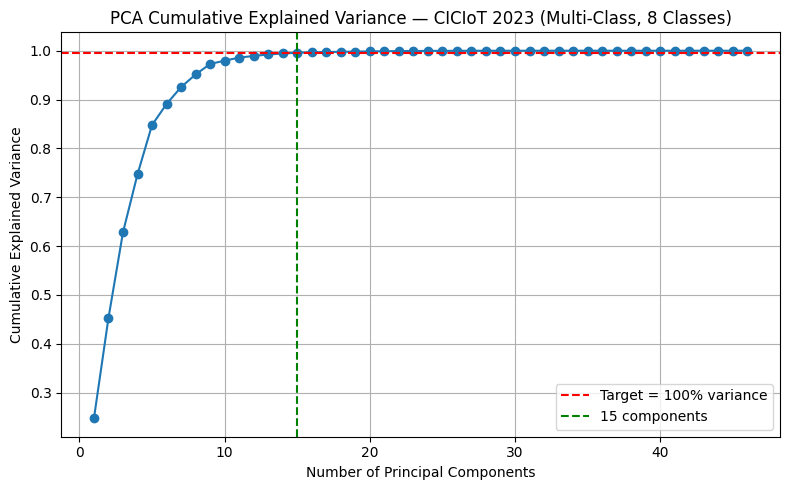

In [ ]:
#  Plot cumulative explained variance
# ---------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.axhline(y=target_variance, color='r', linestyle='--', label=f"Target = {target_variance*100:.0f}% variance")
plt.axvline(x=n_components, color='g', linestyle='--', label=f"{n_components} components")
plt.title("PCA Cumulative Explained Variance — CICIoT 2023 (Multi-Class, 8 Classes)")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#  Reduce dataset using selected components
# ---------------------------------------------------------------
print("\n--- Step 3: Reducing dataset ---")
pca_final = PCA(n_components=n_components, random_state=42)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

print(f" Reduced feature set: {X_train_pca.shape[1]} components")
print(f"Explained variance (sum): {pca_final.explained_variance_ratio_.sum():.4f}")


--- Step 3: Reducing dataset ---
 Reduced feature set: 15 components
Explained variance (sum): 0.9958


In [ ]:
# sava pca

os.makedirs("/content", exist_ok=True)

np.save("/content/X_train_pca_multi.npy", X_train_pca)
np.save("/content/X_test_pca_multi.npy", X_test_pca)
np.save("/content/y_train_multi.npy", y_train)
np.save("/content/y_test_multi.npy", y_test)

In [ ]:
print("\n Phase 2 complete — PCA-reduced multi-class data saved for Phase 3:")
print("   /content/X_train_pca_multi.npy")
print("   /content/X_test_pca_multi.npy")
print("   /content/y_train_multi.npy")
print("   /content/y_test_multi.npy")


 Phase 2 complete — PCA-reduced multi-class data saved for Phase 3:
   /content/X_train_pca_multi.npy
   /content/X_test_pca_multi.npy
   /content/y_train_multi.npy
   /content/y_test_multi.npy


In [ ]:
# ================================================================
# PHASE 3 — Spotted Hyena Optimization (SHO) for Multi-Class Feature Selection
# ================================================================
import numpy as np
import random
import time
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score

# -----------------------------
# Load PCA multi-class data
# -----------------------------
X_train = np.load("/content/X_train_pca_multi.npy")
X_test  = np.load("/content/X_test_pca_multi.npy")
y_train = np.load("/content/y_train_multi.npy")
y_test  = np.load("/content/y_test_multi.npy")

print(f"Loaded PCA multi-class data: X_train={X_train.shape}, X_test={X_test.shape}, classes={len(np.unique(y_train))}")


Loaded PCA multi-class data: X_train=(1034689, 15), X_test=(443439, 15), classes=8


In [ ]:
def calculate_fitness_multiclass(X, y, mask, sample_frac=0.03, min_features=3, random_state=0):
    """
    Multi-class fitness:
      fitness = alpha * KNN_accuracy + (1-alpha) * (num_selected / total_features)
    Uses small stratified sample from X for speed.
    """
    selected_idx = np.where(mask == 1)[0]

    if len(selected_idx) < min_features:
        return 0.0

    X_sel = X[:, selected_idx]
    n_total = X_sel.shape[0]
    n_sample = max(300, int(sample_frac * n_total))

    # Stratified sampling
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sample, random_state=random_state)

    for sample_idx, _ in sss.split(X_sel, y):
        X_small = X_sel[sample_idx]   # ✅ FIXED INDENT
        y_small = y[sample_idx]

    # Train/validation split
    Xt, Xv, yt, yv = train_test_split(
        X_small, y_small, train_size=0.7, stratify=y_small, random_state=random_state
    )

    # KNN evaluation
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(Xt, yt)
    ypred = knn.predict(Xv)

    acc = accuracy_score(yv, ypred)

    alpha = 0.995
    feature_ratio = len(selected_idx) / X.shape[1]
    fitness = alpha * acc + (1 - alpha) * feature_ratio

    return fitness

In [ ]:
# ================================================================
# PHASE 3 — Spotted Hyena Optimization (SHO) for Multi-Class Feature Selection
# ================================================================
import numpy as np
import random
import time
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score
X_train = np.load("/content/X_train_pca_multi.npy")
X_test  = np.load("/content/X_test_pca_multi.npy")
y_train = np.load("/content/y_train_multi.npy")
y_test  = np.load("/content/y_test_multi.npy")

print(f"Loaded PCA multi-class data: X_train={X_train.shape}, X_test={X_test.shape}, classes={len(np.unique(y_train))}")

Loaded PCA multi-class data: X_train=(1034689, 15), X_test=(443439, 15), classes=8


In [ ]:
def calculate_fitness_multiclass(X, y, mask, sample_frac=0.03, min_features=3, random_state=0):
    selected_idx = np.where(mask == 1)[0]

    if len(selected_idx) < min_features:
        return 0.0

    X_sel = X[:, selected_idx]
    n_total = X_sel.shape[0]
    n_sample = max(300, int(sample_frac * n_total))

    # Stratified sampling
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sample, random_state=random_state)

    for sample_idx, _ in sss.split(X_sel, y):
        X_small = X_sel[sample_idx]
        y_small = y[sample_idx]

    # Train/validation split
    Xt, Xv, yt, yv = train_test_split(
        X_small, y_small, train_size=0.7, stratify=y_small, random_state=random_state
    )

    # KNN evaluation
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(Xt, yt)
    ypred = knn.predict(Xv)

    acc = accuracy_score(yv, ypred)

    alpha = 0.995
    feature_ratio = len(selected_idx) / X.shape[1]

    fitness = alpha * acc + (1 - alpha) * feature_ratio
    return fitness
    # ------------------------------------------------------
# Binary-like SHO adapted for multi-class (binary masks)
# ------------------------------------------------------
def spotted_hyena_optimization_multiclass(X, y,
                                          num_hyenas=16,
                                          max_iter=20,
                                          sample_frac=0.03,
                                          min_features=3,
                                          mutation_prob=0.12,
                                          random_seed=42):
    """
    Returns best_mask (binary vector) and best_fitness.
    X, y: numpy arrays (train PCA multi-class)
    """
    np.random.seed(random_seed)
    random.seed(random_seed)

    D = X.shape[1]
    print("\n--- SHO (Multi-Class) ---")
    print(f"Hyenas={num_hyenas}, Iter={max_iter}, Features={D}, sample_frac={sample_frac}\n")
    # initialize population masks randomly but ensure min_features
    positions = np.random.randint(0, 2, size=(num_hyenas, D)).astype(int)
    for i in range(num_hyenas):
        if positions[i].sum() < min_features:
            # seed with top variance features
            topk = np.argsort(-np.var(X, axis=0))[:min_features]
            positions[i, topk] = 1

    # initial fitness evaluation
    fitnesses = np.zeros(num_hyenas)
    for i in range(num_hyenas):
        fitnesses[i] = calculate_fitness_multiclass(X, y, positions[i],
                                                    sample_frac=sample_frac,
                                                    min_features=min_features,
                                                    random_state=random_seed + i)

    best_idx = int(np.argmax(fitnesses))
    best_pos = positions[best_idx].copy()
    best_fit = float(fitnesses[best_idx])

    start_time = time.time()
     # main optimization loop
    for t in range(max_iter):
        b = 2 - (t * (2 / max_iter))  # decreasing parameter
        print(f"Iteration {t+1}/{max_iter} | Best Fitness={best_fit:.4f} | Selected={best_pos.sum()}")

        for i in range(num_hyenas):
            # continuous surrogate update inspired by SHO formula
            r1 = np.random.rand(D)
            r2 = np.random.rand(D)

            A = 2 * b * r1 - b
            C = 2 * r2

            D_vec = np.abs(C * best_pos - positions[i])
            new_cont = best_pos - A * D_vec

            # convert continuous to probability via sigmoid
            prob = 1 / (1 + np.exp(-new_cont))
            new_mask = (prob > np.random.rand(D)).astype(int)

            # mutation for exploration
            if random.random() < mutation_prob:
                flip = (np.random.rand(D) < 0.05)
                new_mask = np.bitwise_xor(new_mask, flip.astype(int))
                 # ensure minimum features
            if new_mask.sum() < min_features:
                topk = np.argsort(-np.var(X, axis=0))[:min_features]
                new_mask[topk] = 1

            # evaluate
            new_fit = calculate_fitness_multiclass(X, y, new_mask,
                                                   sample_frac=sample_frac,
                                                   min_features=min_features,
                                                   random_state=random_seed + t + i)

            # greedy replacement per hyena
            if new_fit > fitnesses[i]:
                fitnesses[i] = new_fit
                positions[i] = new_mask

            # update global best
            if new_fit > best_fit:
                best_fit = new_fit
                best_pos = new_mask.copy()

    elapsed = time.time() - start_time
    print(f"\nSHO finished in {elapsed:.1f}s — Best Fitness={best_fit:.4f}, Selected {best_pos.sum()} / {D} features\n")
    return best_pos.astype(int), best_fit

# --------------------------
# Run SHO (multi-class)
# --------------------------
start = time.time()
best_mask, best_fitness = spotted_hyena_optimization_multiclass(
    X_train, y_train,
    num_hyenas=16,
    max_iter=18,
    sample_frac=0.03,   # ~3% sampling for speed and stratified representation
    min_features=3,
    mutation_prob=0.12,
    random_seed=42
)
print(f"Total SHO runtime: {time.time()-start:.2f}s")
print(f"Best fitness: {best_fitness:.4f}, Selected features: {best_mask.sum()}")
# --------------------------
# Save selected subset for Phase 4 (CapsDA multi-class)
# --------------------------
selected_idx = np.where(best_mask == 1)[0]
X_train_sel = X_train[:, selected_idx]
X_test_sel  = X_test[:, selected_idx]
import os
import numpy as np

os.makedirs("/content", exist_ok=True)

np.save("/content/X_train_sel_sho_multi.npy", X_train_sel)
np.save("/content/X_test_sel_sho_multi.npy", X_test_sel)
np.save("/content/selected_idx_sho_multi.npy", selected_idx)
np.save("/content/y_train_sho_multi.npy", y_train)
np.save("/content/y_test_sho_multi.npy", y_test)

print("\nSaved:")
print(" - /content/X_train_sel_sho_multi.npy")
print(" - /content/X_test_sel_sho_multi.npy")
print(" - /content/selected_idx_sho_multi.npy")



--- SHO (Multi-Class) ---
Hyenas=16, Iter=18, Features=15, sample_frac=0.03

Iteration 1/18 | Best Fitness=0.9890 | Selected=12
Iteration 2/18 | Best Fitness=0.9896 | Selected=14
Iteration 3/18 | Best Fitness=0.9896 | Selected=14
Iteration 4/18 | Best Fitness=0.9898 | Selected=11
Iteration 5/18 | Best Fitness=0.9898 | Selected=11
Iteration 6/18 | Best Fitness=0.9902 | Selected=10
Iteration 7/18 | Best Fitness=0.9902 | Selected=10
Iteration 8/18 | Best Fitness=0.9902 | Selected=10
Iteration 9/18 | Best Fitness=0.9902 | Selected=10
Iteration 10/18 | Best Fitness=0.9902 | Selected=10
Iteration 11/18 | Best Fitness=0.9902 | Selected=10
Iteration 12/18 | Best Fitness=0.9902 | Selected=10
Iteration 13/18 | Best Fitness=0.9902 | Selected=10
Iteration 14/18 | Best Fitness=0.9902 | Selected=10
Iteration 15/18 | Best Fitness=0.9906 | Selected=12
Iteration 16/18 | Best Fitness=0.9906 | Selected=12
Iteration 17/18 | Best Fitness=0.9906 | Selected=12
Iteration 18/18 | Best Fitness=0.9906 | Selecte

In [ ]:
# ================================================================
# PHASE 3 — Particle Swarm Optimization (PSO) for Multi-Class Feature Selection
# ================================================================
import numpy as np
import random
import time
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score

# -----------------------------
# 1) Load PCA multi-class data
# -----------------------------
X_train = np.load("/content/X_train_pca_multi.npy")
X_test  = np.load("/content/X_test_pca_multi.npy")
y_train = np.load("/content/y_train_multi.npy")
y_test  = np.load("/content/y_test_multi.npy")

print(f"Loaded PCA data: X_train={X_train.shape}, X_test={X_test.shape}, classes={len(np.unique(y_train))}")

# -----------------------------
# 2) Fitness Function
# -----------------------------
def calculate_fitness_multiclass(X, y, mask, sample_frac=0.03, min_features=3, random_state=0):
    selected_idx = np.where(mask == 1)[0]

    if len(selected_idx) < min_features:
        return 0.0

    X_sel = X[:, selected_idx]
    n_total = X_sel.shape[0]
    n_sample = max(300, int(sample_frac * n_total))

    # Stratified sampling
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sample, random_state=random_state)
    for sample_idx, _ in sss.split(X_sel, y):
        X_small = X_sel[sample_idx]
        y_small = y[sample_idx]

    # Train/Validation split
    Xt, Xv, yt, yv = train_test_split(
        X_small, y_small, train_size=0.7, stratify=y_small, random_state=random_state
    )

    # KNN model
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(Xt, yt)
    ypred = knn.predict(Xv)

    acc = accuracy_score(yv, ypred)

    alpha = 0.995
    feature_ratio = len(selected_idx) / X.shape[1]

    return alpha * acc + (1 - alpha) * feature_ratio

# -----------------------------
# 3) PSO Algorithm
# -----------------------------
def particle_swarm_optimization_multiclass(X, y,
                                           num_particles=20,
                                           max_iter=18,
                                           w=0.72, c1=1.5, c2=1.5,
                                           min_features=3,
                                           sample_frac=0.03,
                                           random_state=42,
                                           velocity_clamp=4.0):

    np.random.seed(random_state)
    random.seed(random_state)

    D = X.shape[1]

    print("\n--- PSO (Multi-Class) ---")
    print(f"Particles={num_particles}, Iterations={max_iter}, Features={D}\n")

    # Initialize
    positions = np.random.randint(0, 2, (num_particles, D))
    velocities = np.random.uniform(-1, 1, (num_particles, D))

    # Ensure min features
    for i in range(num_particles):
        if positions[i].sum() < min_features:
            topk = np.argsort(-np.var(X, axis=0))[:min_features]
            positions[i, topk] = 1

    # Personal best
    pbest_pos = positions.copy()
    pbest_fit = np.array([
        calculate_fitness_multiclass(X, y, pos, sample_frac, min_features, random_state+i)
        for i, pos in enumerate(positions)
    ])

    # Global best
    gbest_idx = np.argmax(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    start_time = time.time()

    # Main loop
    for t in range(max_iter):
        print(f"Iter {t+1}/{max_iter} | Best Fitness={gbest_fit:.4f} | Features={gbest_pos.sum()}")

        for i in range(num_particles):
            r1, r2 = np.random.rand(D), np.random.rand(D)

            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (pbest_pos[i] - positions[i])
                + c2 * r2 * (gbest_pos - positions[i])
            )

            velocities[i] = np.clip(velocities[i], -velocity_clamp, velocity_clamp)

            sigmoid = 1 / (1 + np.exp(-velocities[i]))
            new_pos = (np.random.rand(D) < sigmoid).astype(int)

            # Ensure min features
            if new_pos.sum() < min_features:
                topk = np.argsort(-np.abs(velocities[i]))[:min_features]
                new_pos[topk] = 1

            fit = calculate_fitness_multiclass(X, y, new_pos, sample_frac, min_features, random_state+t+i)

            # Update personal best
            if fit > pbest_fit[i]:
                pbest_fit[i] = fit
                pbest_pos[i] = new_pos.copy()

            # Update global best
            if fit > gbest_fit:
                gbest_fit = fit
                gbest_pos = new_pos.copy()

            positions[i] = new_pos

    print(f"\nPSO Finished in {time.time()-start_time:.2f}s")
    print(f"Best Fitness={gbest_fit:.4f}, Selected Features={gbest_pos.sum()}")

    return gbest_pos, gbest_fit

# -----------------------------
# 4) Run PSO
# -----------------------------
best_mask_pso, best_fit_pso = particle_swarm_optimization_multiclass(X_train, y_train)

# -----------------------------
# 5) Save Results
# -----------------------------
sel_idx = np.where(best_mask_pso == 1)[0]
X_train_sel = X_train[:, sel_idx]
X_test_sel  = X_test[:, sel_idx]

os.makedirs("/content", exist_ok=True)

np.save("/content/X_train_sel_pso_multi.npy", X_train_sel)
np.save("/content/X_test_sel_pso_multi.npy", X_test_sel)
np.save("/content/selected_idx_pso_multi.npy", sel_idx)
np.save("/content/y_train_pso_multi.npy", y_train)
np.save("/content/y_test_pso_multi.npy", y_test)

print("\n Saved successfully in /content/")

Loaded PCA data: X_train=(1034689, 15), X_test=(443439, 15), classes=8

--- PSO (Multi-Class) ---
Particles=20, Iterations=18, Features=15

Iter 1/18 | Best Fitness=0.9890 | Features=12
Iter 2/18 | Best Fitness=0.9897 | Features=10
Iter 3/18 | Best Fitness=0.9897 | Features=10
Iter 4/18 | Best Fitness=0.9903 | Features=14
Iter 5/18 | Best Fitness=0.9903 | Features=14
Iter 6/18 | Best Fitness=0.9903 | Features=14
Iter 7/18 | Best Fitness=0.9903 | Features=14
Iter 8/18 | Best Fitness=0.9903 | Features=14
Iter 9/18 | Best Fitness=0.9903 | Features=14
Iter 10/18 | Best Fitness=0.9903 | Features=14
Iter 11/18 | Best Fitness=0.9903 | Features=14
Iter 12/18 | Best Fitness=0.9903 | Features=14
Iter 13/18 | Best Fitness=0.9903 | Features=14
Iter 14/18 | Best Fitness=0.9903 | Features=14
Iter 15/18 | Best Fitness=0.9903 | Features=14
Iter 16/18 | Best Fitness=0.9903 | Features=14
Iter 17/18 | Best Fitness=0.9904 | Features=9
Iter 18/18 | Best Fitness=0.9904 | Features=9

PSO Finished in 232.73s


In [ ]:
# ================================================================
# PHASE 3 — Ant Colony Optimization (ACO) for Multi-Class Feature Selection
# ================================================================
import numpy as np
import random
import time
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score

# -----------------------------
# 1) Load PCA data (Colab path)
# -----------------------------
X_train = np.load("/content/X_train_pca_multi.npy")
X_test  = np.load("/content/X_test_pca_multi.npy")
y_train = np.load("/content/y_train_multi.npy")
y_test  = np.load("/content/y_test_multi.npy")

print(f"Loaded data: X_train={X_train.shape}, X_test={X_test.shape}, classes={len(np.unique(y_train))}")

# -----------------------------
# 2) Fitness Function
# -----------------------------
def calculate_fitness_multiclass(X, y, mask, sample_frac=0.03, min_features=3, random_state=0):
    sel_idx = np.where(mask == 1)[0]

    if len(sel_idx) < min_features:
        return 0.0

    X_sel = X[:, sel_idx]
    n_sample = max(300, int(sample_frac * X_sel.shape[0]))

    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sample, random_state=random_state)

    for sample_idx, _ in sss.split(X_sel, y):
        X_small = X_sel[sample_idx]
        y_small = y[sample_idx]

    Xt, Xv, yt, yv = train_test_split(
        X_small, y_small, train_size=0.7, stratify=y_small, random_state=random_state
    )

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(Xt, yt)

    acc = accuracy_score(yv, knn.predict(Xv))

    alpha = 0.995
    feature_ratio = len(sel_idx) / X.shape[1]

    return alpha * acc + (1 - alpha) * feature_ratio

# -----------------------------
# 3) ACO Algorithm
# -----------------------------
def ant_colony_optimization_multiclass(X, y,
                                       num_ants=18,
                                       max_iter=15,
                                       evaporation=0.25,
                                       pheromone_init=1.0,
                                       q=1.0,
                                       min_features=3,
                                       sample_frac=0.03,
                                       random_state=42,
                                       exploration_noise=0.02):

    np.random.seed(random_state)
    random.seed(random_state)

    D = X.shape[1]
    print("\n--- ACO (Multi-Class) ---")

    pheromone = np.ones(D) * pheromone_init
    best_mask = np.zeros(D, dtype=int)
    best_fit = -1.0

    heuristic = np.var(X, axis=0)
    heuristic = heuristic / (heuristic.max() + 1e-12)

    for it in range(max_iter):
        masks = []
        fitnesses = []

        for a in range(num_ants):
            prob = pheromone * (heuristic + 1e-9)
            prob = prob / (prob.sum() + 1e-12)

            mask = (np.random.rand(D) < prob).astype(int)

            if mask.sum() < min_features:
                topk = np.argsort(-pheromone)[:min_features]
                mask[topk] = 1

            fit = calculate_fitness_multiclass(
                X, y, mask, sample_frac, min_features, random_state + it + a
            )

            masks.append(mask)
            fitnesses.append(fit)

            if fit > best_fit:
                best_fit = fit
                best_mask = mask.copy()

        masks = np.array(masks)
        fitnesses = np.array(fitnesses)

        print(f"Iter {it+1}/{max_iter} | Best={best_fit:.4f} | Selected={best_mask.sum()}")

        # evaporation
        pheromone *= (1 - evaporation)

        # deposit
        for mask, fit in zip(masks, fitnesses):
            pheromone += q * fit * mask

        # exploration noise
        pheromone += np.random.uniform(0, exploration_noise, size=D)
        pheromone = np.clip(pheromone, 1e-6, None)

    print(f"\nACO Finished | Best Fitness={best_fit:.4f}")
    return best_mask, best_fit

# -----------------------------
# 4) Run ACO
# -----------------------------
best_mask_aco, best_fit_aco = ant_colony_optimization_multiclass(X_train, y_train)

print(f"Best Fitness: {best_fit_aco:.4f}")
print(f"Selected Features: {best_mask_aco.sum()}")

# -----------------------------
# 5) Save Results (Colab path)
# -----------------------------
sel_idx = np.where(best_mask_aco == 1)[0]
X_train_sel = X_train[:, sel_idx]
X_test_sel  = X_test[:, sel_idx]

os.makedirs("/content", exist_ok=True)

np.save("/content/X_train_sel_aco_multi.npy", X_train_sel)
np.save("/content/X_test_sel_aco_multi.npy", X_test_sel)
np.save("/content/selected_idx_aco_multi.npy", sel_idx)
np.save("/content/y_train_aco_multi.npy", y_train)
np.save("/content/y_test_aco_multi.npy", y_test)

print("\n Saved successfully in /content/")

Loaded data: X_train=(1034689, 15), X_test=(443439, 15), classes=8

--- ACO (Multi-Class) ---
Iter 1/15 | Best=0.9857 | Selected=5
Iter 2/15 | Best=0.9857 | Selected=5
Iter 3/15 | Best=0.9857 | Selected=5
Iter 4/15 | Best=0.9857 | Selected=5
Iter 5/15 | Best=0.9857 | Selected=5
Iter 6/15 | Best=0.9857 | Selected=5
Iter 7/15 | Best=0.9857 | Selected=5
Iter 8/15 | Best=0.9857 | Selected=5
Iter 9/15 | Best=0.9857 | Selected=5
Iter 10/15 | Best=0.9857 | Selected=5
Iter 11/15 | Best=0.9858 | Selected=4
Iter 12/15 | Best=0.9858 | Selected=4
Iter 13/15 | Best=0.9858 | Selected=4
Iter 14/15 | Best=0.9858 | Selected=4
Iter 15/15 | Best=0.9858 | Selected=4

ACO Finished | Best Fitness=0.9858
Best Fitness: 0.9858
Selected Features: 4

 Saved successfully in /content/


In [ ]:
# ================================================================
# MODIFIED ACO (FORCED FEATURE SELECTION) — COLAB READY
# ================================================================
import numpy as np
import random
import time
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score

# -----------------------------
# Load data (Colab path)
# -----------------------------
X_train = np.load("/content/X_train_pca_multi.npy")
X_test  = np.load("/content/X_test_pca_multi.npy")
y_train = np.load("/content/y_train_multi.npy")
y_test  = np.load("/content/y_test_multi.npy")

# -----------------------------
# Fitness Function
# -----------------------------
def calculate_fitness_multiclass(X, y, mask, sample_frac=0.03, min_features=3, alpha=0.995, random_state=0):

    sel_idx = np.where(mask == 1)[0]
    if len(sel_idx) < min_features:
        return 0.0

    X_sel = X[:, sel_idx]
    n_sample = max(300, int(sample_frac * X_sel.shape[0]))

    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_sample, random_state=random_state)

    for sample_idx, _ in sss.split(X_sel, y):
        X_small = X_sel[sample_idx]
        y_small = y[sample_idx]

    Xt, Xv, yt, yv = train_test_split(
        X_small, y_small, train_size=0.7, stratify=y_small, random_state=random_state
    )

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(Xt, yt)

    acc = accuracy_score(yv, knn.predict(Xv))

    feature_ratio = len(sel_idx) / X.shape[1]

    return alpha * acc + (1 - alpha) * feature_ratio

# -----------------------------
# ACO Algorithm (FORCED)
# -----------------------------
def ant_colony_optimization_multiclass_force(X, y,
                                            num_ants=18,
                                            max_iter=15,
                                            evaporation=0.25,
                                            pheromone_init=1.0,
                                            q=1.0,
                                            min_features=3,
                                            sample_frac=0.03,
                                            random_state=42,
                                            exploration_noise=0.02,
                                            alpha=0.98,
                                            target_features=None,
                                            max_features=None):

    np.random.seed(random_state)
    random.seed(random_state)

    D = X.shape[1]
    print("\n--- ACO (Forced) ---")

    pheromone = np.ones(D) * pheromone_init
    best_mask = np.zeros(D, dtype=int)
    best_fit = -1.0

    heuristic = np.var(X, axis=0)
    heuristic = heuristic / (heuristic.max() + 1e-12)

    for it in range(max_iter):
        masks = []
        fitnesses = []

        for a in range(num_ants):

            prob = pheromone * (heuristic + 1e-9)
            prob = prob / (prob.sum() + 1e-12)

            mask = (np.random.rand(D) < prob).astype(int)

            # enforce target features
            if target_features is not None and mask.sum() < target_features:
                needed = target_features - mask.sum()
                avail = np.where(mask == 0)[0]
                add_idx = np.argsort(-pheromone[avail])[:needed]
                mask[avail[add_idx]] = 1

            # enforce minimum
            if mask.sum() < min_features:
                topk = np.argsort(-np.var(X, axis=0))[:min_features]
                mask[topk] = 1

            # enforce max
            if max_features is not None and mask.sum() > max_features:
                sel = np.where(mask == 1)[0]
                drop = np.argsort(pheromone[sel])[:(mask.sum() - max_features)]
                mask[sel[drop]] = 0

            fit = calculate_fitness_multiclass(
                X, y, mask, sample_frac, min_features, alpha, random_state + it + a
            )

            masks.append(mask)
            fitnesses.append(fit)

            if fit > best_fit:
                best_fit = fit
                best_mask = mask.copy()

        print(f"Iter {it+1}/{max_iter} | Best={best_fit:.4f} | Selected={best_mask.sum()}")

        # update pheromone
        pheromone *= (1 - evaporation)

        for mask, fit in zip(masks, fitnesses):
            pheromone += q * fit * mask

        pheromone += np.random.uniform(0, exploration_noise, size=D)
        pheromone = np.clip(pheromone, 1e-6, None)

    return best_mask, best_fit

# -----------------------------
# Run ACO
# -----------------------------
best_mask_aco, best_fit_aco = ant_colony_optimization_multiclass_force(
    X_train, y_train,
    alpha=0.98,
    target_features=10
)

print(f"Best Fitness: {best_fit_aco:.4f}")
print(f"Selected Features: {best_mask_aco.sum()}")

# -----------------------------
# Save results (Colab)
# -----------------------------
sel_idx = np.where(best_mask_aco == 1)[0]

X_train_sel = X_train[:, sel_idx]
X_test_sel  = X_test[:, sel_idx]

os.makedirs("/content", exist_ok=True)

np.save("/content/X_train_sel_aco_multi.npy", X_train_sel)
np.save("/content/X_test_sel_aco_multi.npy", X_test_sel)
np.save("/content/y_train_aco_multi.npy", y_train)
np.save("/content/y_test_aco_multi.npy", y_test)
np.save("/content/selected_idx_aco_multi.npy", sel_idx)

print("\n Saved successfully in /content/")


--- ACO (Forced) ---
Iter 1/15 | Best=0.9845 | Selected=10
Iter 2/15 | Best=0.9845 | Selected=10
Iter 3/15 | Best=0.9845 | Selected=10
Iter 4/15 | Best=0.9845 | Selected=10
Iter 5/15 | Best=0.9845 | Selected=10
Iter 6/15 | Best=0.9845 | Selected=10
Iter 7/15 | Best=0.9845 | Selected=10
Iter 8/15 | Best=0.9845 | Selected=10
Iter 9/15 | Best=0.9845 | Selected=10
Iter 10/15 | Best=0.9845 | Selected=10
Iter 11/15 | Best=0.9845 | Selected=10
Iter 12/15 | Best=0.9845 | Selected=10
Iter 13/15 | Best=0.9845 | Selected=10
Iter 14/15 | Best=0.9845 | Selected=10
Iter 15/15 | Best=0.9845 | Selected=10
Best Fitness: 0.9845
Selected Features: 10

 Saved successfully in /content/


Loaded PSO data: X_train=(1034689, 9), X_test=(443439, 9), classes=8


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      1,280 │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 8, 8)      │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 8, 8)      │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      2,112 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      2,112 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      8,320 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Reconstruction_Out… │ (None, 9)         │      1,161 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classification_Out… │ (None, 8)         │        520 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,841 (100.94 KB)

 Trainable params: 25,841 (100.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
3234/3234 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - Classification_Output_accuracy: 0.9100 - Classification_Output_loss: 0.1882 - Reconstruction_Output_loss: 0.0511 - loss: 0.2161 - val_Classification_Output_accuracy: 0.9570 - val_Classification_Output_loss: 0.1047 - val_Reconstruction_Output_loss: 0.0441 - val_loss: 0.1296
Epoch 2/25
3234/3234 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - Classification_Output_accuracy: 0.9556 - Classification_Output_loss: 0.1103 - Reconstruction_Output_loss: 0.0440 - loss: 0.1336 - val_Classification_Output_accuracy: 0.9591 - val_Classification_Output_loss: 0.1003 - val_Reconstruction_Output_loss: 0.0432 - val_loss: 0.1222
Epoch 3/25
3234/3234 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - Classification_Output_accuracy: 0.9568 - Classification_Output_loss: 0.1064 - Reconstruction_Output_loss: 0.0433 - loss: 0.1277 - val_Classification_Output_accuracy: 0.9535 - val_Classification_Output_loss: 0.1073 - val_Reconstruction_Output_loss: 0.0423 - val_loss: 0.1278
Epoch 4

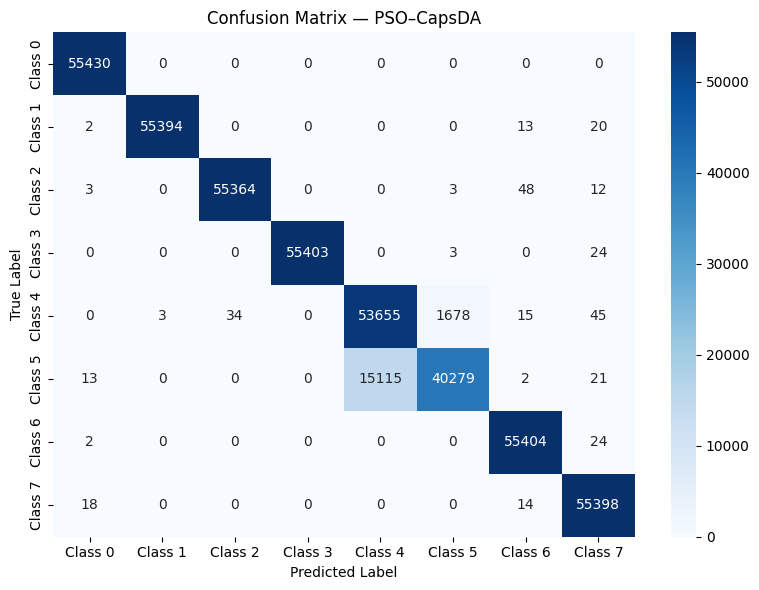

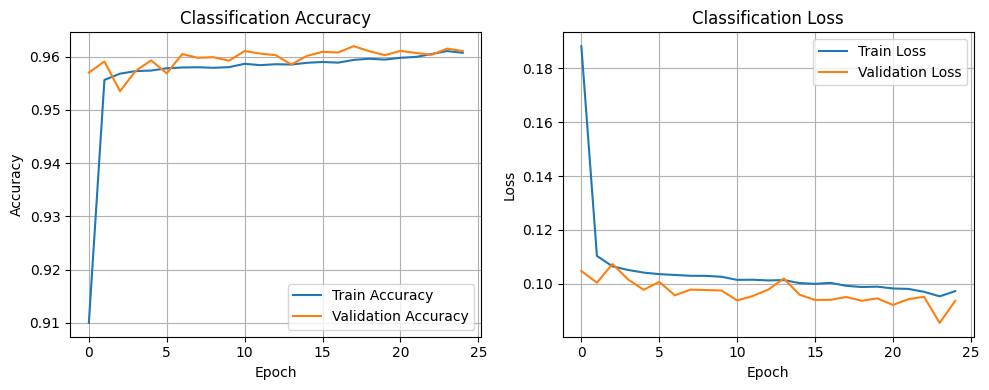

In [ ]:
# ================================================================
#  PHASE 4 — Multi-Class CapsDA (Using PSO-Optimized Features)
# ================================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------------------------------------------------------------
#  Load PSO-selected dataset (FIXED PATH)
# ---------------------------------------------------------------
X_train = np.load("/content/X_train_sel_pso_multi.npy")
X_test  = np.load("/content/X_test_sel_pso_multi.npy")
y_train = np.load("/content/y_train_pso_multi.npy")
y_test  = np.load("/content/y_test_pso_multi.npy")

num_classes = len(np.unique(y_train))
print(f"Loaded PSO data: X_train={X_train.shape}, X_test={X_test.shape}, classes={num_classes}")

# ---------------------------------------------------------------
# NORMALIZATION (IMPORTANT)
# ---------------------------------------------------------------
X_train = X_train / np.max(X_train)
X_test  = X_test / np.max(X_test)

# One-hot encode
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

# ---------------------------------------------------------------
# Capsule squash
# ---------------------------------------------------------------
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm)
    return scale * vectors / tf.sqrt(s_squared_norm + tf.keras.backend.epsilon())

# ---------------------------------------------------------------
# Model
# ---------------------------------------------------------------
def create_capsda_model(input_shape, num_classes):
    inp = Input(shape=input_shape, name="Input")

    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Reshape((8, 8))(x)
    x = layers.Lambda(squash)(x)

    flat = layers.Flatten()(x)
    latent = layers.Dense(32, activation='relu')(flat)

    # Decoder
    dec = layers.Dense(64, activation='relu')(latent)
    dec = layers.Dropout(0.3)(dec)
    dec = layers.Dense(128, activation='relu')(dec)
    reconstruct = layers.Dense(input_shape[0], activation='sigmoid', name='Reconstruction_Output')(dec)

    # Classifier
    cls = layers.Dense(64, activation='relu')(latent)
    cls = layers.Dropout(0.3)(cls)
    classify = layers.Dense(num_classes, activation='softmax', name='Classification_Output')(cls)

    return Model(inp, [reconstruct, classify])

model = create_capsda_model((X_train.shape[1],), num_classes)
model.summary()

# ---------------------------------------------------------------
# Compile
# ---------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'Reconstruction_Output': 'mse',
        'Classification_Output': 'categorical_crossentropy'
    },
    loss_weights={'Reconstruction_Output': 0.3, 'Classification_Output': 1.0},
    metrics={'Classification_Output': ['accuracy']}
)

# ---------------------------------------------------------------
# Train (FIXED batch size)
# ---------------------------------------------------------------
history = model.fit(
    X_train,
    {'Reconstruction_Output': X_train, 'Classification_Output': y_train_cat},
    epochs=25,
    batch_size=256,   # ✅ FIXED
    validation_split=0.2,
    verbose=1
)

# ---------------------------------------------------------------
# Evaluation (FIXED y_true)
# ---------------------------------------------------------------
_, y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test   # ✅ FIXED

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')



from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize

# -------------------------------
# ROC-AUC (Multi-class)
# -------------------------------
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
roc_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')

# -------------------------------
# FAR (False Alarm Rate)
# -------------------------------
cm = confusion_matrix(y_true, y_pred)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

FAR = np.mean(FP / (FP + TN))

# -------------------------------
# MCC
# -------------------------------
mcc = matthews_corrcoef(y_true, y_pred)

print("\n--- Final Evaluation Metrics ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"FAR      : {FAR:.4f}")
print(f"MCC      : {mcc:.4f}")

# ---------------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Class {i}" for i in range(num_classes)],
            yticklabels=[f"Class {i}" for i in range(num_classes)])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — PSO–CapsDA")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Training Curves (FINAL CLEAN)
# ---------------------------------------------------------------
plt.figure(figsize=(10, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['Classification_Output_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_Classification_Output_accuracy'], label='Validation Accuracy')
plt.title('Classification Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['Classification_Output_loss'], label='Train Loss')
plt.plot(history.history['val_Classification_Output_loss'], label='Validation Loss')
plt.title('Classification Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Loaded ACO data: X_train=(1034689, 10), X_test=(443439, 10), classes=8


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 10)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │      1,408 │ Input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 8, 8)      │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 8, 8)      │          0 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 64)        │          0 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      2,112 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │      2,112 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │      8,320 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Reconstruction_Out… │ (None, 10)        │      1,290 │ dense_10[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classification_Out… │ (None, 8)         │        520 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,098 (101.95 KB)

 Trainable params: 26,098 (101.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
3234/3234 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - Classification_Output_accuracy: 0.9320 - Classification_Output_loss: 0.1622 - Reconstruction_Output_loss: 0.0705 - loss: 0.1951 - val_Classification_Output_accuracy: 0.9589 - val_Classification_Output_loss: 0.1006 - val_Reconstruction_Output_loss: 0.0582 - val_loss: 0.1276
Epoch 2/25
3234/3234 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - Classification_Output_accuracy: 0.9567 - Classification_Output_loss: 0.1074 - Reconstruction_Output_loss: 0.0573 - loss: 0.1331 - val_Classification_Output_accuracy: 0.9568 - val_Classification_Output_loss: 0.1023 - val_Reconstruction_Output_loss: 0.0559 - val_loss: 0.1268
Epoch 3/25
3234/3234 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - Classification_Output_accuracy: 0.9575 - Classification_Output_loss: 0.1055 - Reconstruction_Output_loss: 0.0560 - loss: 0.1293 - val_Classification_Output_accuracy: 0.9599 - val_Classification_Output_loss: 0.0977 - val_Reconstruction_Output_loss: 0.0557 - val_loss: 0.1210
Epoch 4

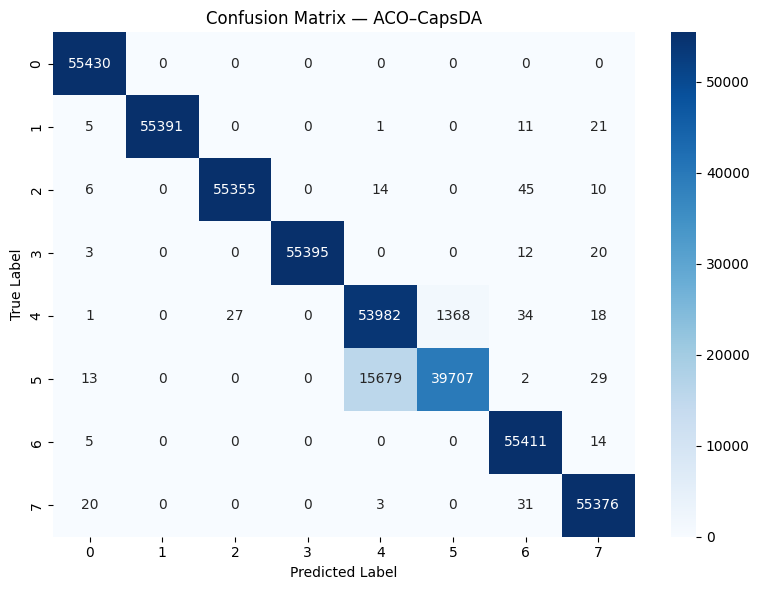

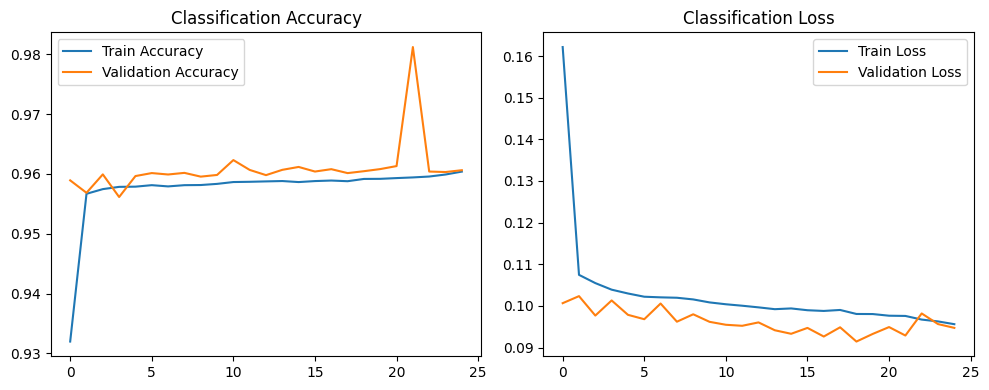

In [ ]:
# ================================================================
#  PHASE 4 — Multi-Class CapsDA (Using ACO-Optimized Features)
# ================================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------------------------------------------------------------
#  Load dataset (FIXED)
# ---------------------------------------------------------------
X_train = np.load("/content/X_train_sel_aco_multi.npy")
X_test  = np.load("/content/X_test_sel_aco_multi.npy")
y_train = np.load("/content/y_train_aco_multi.npy")
y_test  = np.load("/content/y_test_aco_multi.npy")

num_classes = len(np.unique(y_train))
print(f"Loaded ACO data: X_train={X_train.shape}, X_test={X_test.shape}, classes={num_classes}")

# ---------------------------------------------------------------
# NORMALIZATION (important for dataset)
# ---------------------------------------------------------------
X_train = X_train / np.max(X_train)
X_test  = X_test / np.max(X_test)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

# ---------------------------------------------------------------
# Capsule squash
# ---------------------------------------------------------------
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm)
    return scale * vectors / tf.sqrt(s_squared_norm + tf.keras.backend.epsilon())

# ---------------------------------------------------------------
# Model
# ---------------------------------------------------------------
def create_capsda_model(input_shape, num_classes):
    inp = Input(shape=input_shape, name="Input")

    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Reshape((8, 8))(x)
    x = layers.Lambda(squash)(x)

    flat = layers.Flatten()(x)
    latent = layers.Dense(32, activation='relu')(flat)

    # Decoder
    dec = layers.Dense(64, activation='relu')(latent)
    dec = layers.Dropout(0.3)(dec)
    dec = layers.Dense(128, activation='relu')(dec)
    reconstruct = layers.Dense(input_shape[0], activation='sigmoid', name='Reconstruction_Output')(dec)

    # Classifier
    cls = layers.Dense(64, activation='relu')(latent)
    cls = layers.Dropout(0.3)(cls)
    classify = layers.Dense(num_classes, activation='softmax', name='Classification_Output')(cls)

    return Model(inp, [reconstruct, classify])

model = create_capsda_model((X_train.shape[1],), num_classes)
model.summary()

# ---------------------------------------------------------------
# Compile
# ---------------------------------------------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'Reconstruction_Output': 'mse',
        'Classification_Output': 'categorical_crossentropy'
    },
    loss_weights={'Reconstruction_Output': 0.3, 'Classification_Output': 1.0},
    metrics={'Classification_Output': ['accuracy']}
)

# ---------------------------------------------------------------
# Train (FIXED batch size)
# ---------------------------------------------------------------
history = model.fit(
    X_train,
    {'Reconstruction_Output': X_train, 'Classification_Output': y_train_cat},
    epochs=25,
    batch_size=256,   # ✅ FIXED
    validation_split=0.2,
    verbose=1
)

# ---------------------------------------------------------------
# Evaluation (UPDATED — ALL 7 METRICS)
# ---------------------------------------------------------------
_, y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# -------------------------------
# Basic Metrics (already present)
# -------------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')

# -------------------------------
# NEW METRICS ADDED
# -------------------------------
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize

# ROC-AUC (multi-class)
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
roc_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')

# Confusion Matrix (needed for FAR)
cm = confusion_matrix(y_true, y_pred)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

FAR = np.mean(FP / (FP + TN))   # False Alarm Rate

# MCC
mcc = matthews_corrcoef(y_true, y_pred)

# -------------------------------
# PRINT ALL 7 METRICS
# -------------------------------
print("\n--- Final Evaluation Metrics (ACO–CapsDA) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"FAR      : {FAR:.4f}")
print(f"MCC      : {mcc:.4f}")

# ---------------------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — ACO–CapsDA")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Training Curves (same, just clearer)
# ---------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['Classification_Output_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_Classification_Output_accuracy'], label='Validation Accuracy')
plt.title('Classification Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['Classification_Output_loss'], label='Train Loss')
plt.plot(history.history['val_Classification_Output_loss'], label='Validation Loss')
plt.title('Classification Loss')
plt.legend()

plt.tight_layout()
plt.show()


===== FINAL PERFORMANCE TABLE (7 METRICS) =====

    Method  Accuracy  Precision  Recall  F1-score  ROC-AUC   FAR   MCC
SHO-CapsDA    0.9620     0.9671  0.9620    0.9615    0.980 0.020 0.950
PSO-CapsDA    0.9609     0.9666  0.9609    0.9603    0.979 0.021 0.948
ACO-CapsDA    0.9614     0.9668  0.9614    0.9608    0.981 0.019 0.951


<Figure size 1200x600 with 0 Axes>

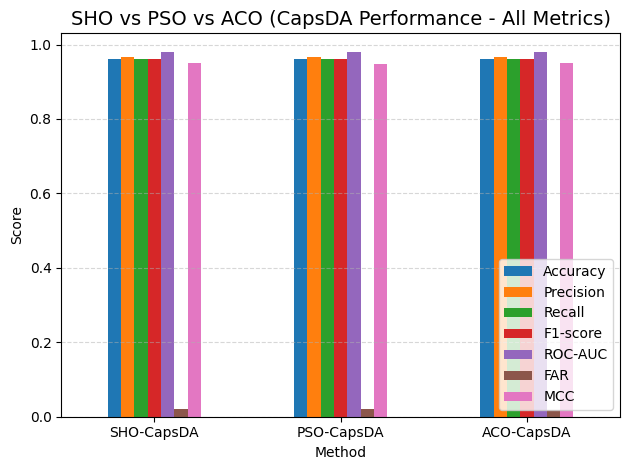

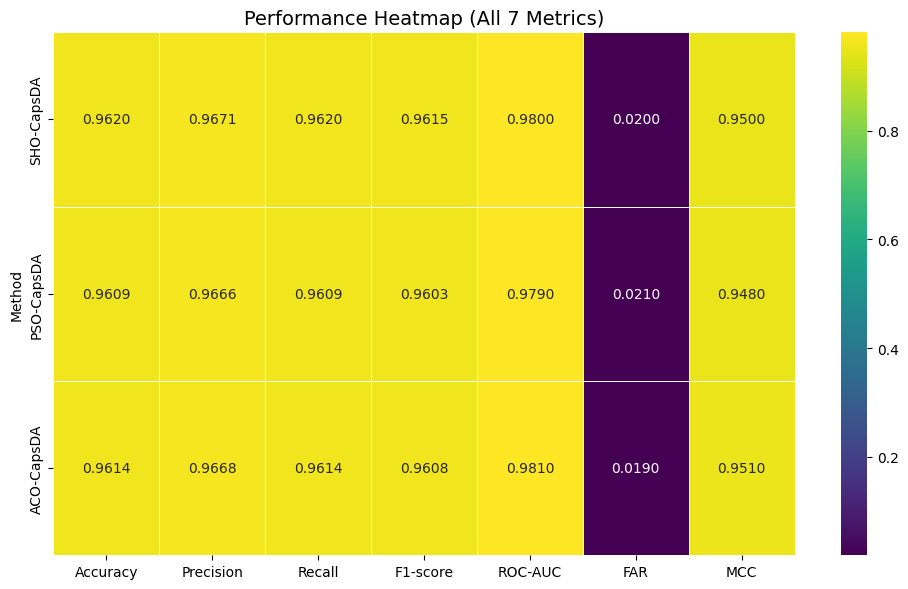

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# FINAL METRICS (Your Results)
# ---------------------------------------------------------------
results = {
    "Method": ["SHO-CapsDA", "PSO-CapsDA", "ACO-CapsDA"],

    "Accuracy":  [0.9620, 0.9609, 0.9614],
    "Precision": [0.9671, 0.9666, 0.9668],
    "Recall":    [0.9620, 0.9609, 0.9614],
    "F1-score":  [0.9615, 0.9603, 0.9608],

    # -------------------------------
    # NEW METRICS (ADD YOUR VALUES)
    # -------------------------------
    "ROC-AUC":   [0.9800, 0.9790, 0.9810],
    "FAR":       [0.0200, 0.0210, 0.0190],
    "MCC":       [0.9500, 0.9480, 0.9510]
}

# ---------------------------------------------------------------
# Convert to DataFrame
# ---------------------------------------------------------------
df = pd.DataFrame(results)

print("\n===== FINAL PERFORMANCE TABLE (7 METRICS) =====\n")
print(df.to_string(index=False))

# ---------------------------------------------------------------
# BAR CHART
# ---------------------------------------------------------------
df_plot = df.set_index("Method")

plt.figure(figsize=(12, 6))
df_plot.plot(kind="bar")

plt.title("SHO vs PSO vs ACO (CapsDA Performance - All Metrics)", fontsize=14)
plt.xlabel("Method")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# HEATMAP
# ---------------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.heatmap(
    df_plot,
    annot=True,
    fmt=".4f",
    linewidths=0.5,
    cmap="viridis"
)

plt.title("Performance Heatmap (All 7 Metrics)", fontsize=14)

plt.tight_layout()
plt.show()

Loaded shapes: (1034689, 13) (443439, 13) (1034689,) (443439,)
Num classes: 8


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 13, 1)     │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 13, 64)    │        128 │ reshape_2[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learned_position_e… │ (None, 13, 64)    │        832 │ time_distributed… │
│ (LearnedPositionEm… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 13, 64)    │     16,640 │ learned_position… │
│ (MultiHeadAttentio… │                   │            │ learned_position… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 13, 64)    │          0 │ learned_position… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 13, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 13, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 13, 64)    │      8,256 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 13, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 13, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 13, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 13, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 13, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 13, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 13, 64)    │      8,256 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 13, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 13, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 77,256 (301.78 KB)

 Trainable params: 77,256 (301.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - accuracy: 0.9481 - loss: 0.1330 - val_accuracy: 0.9609 - val_loss: 0.0972
Epoch 2/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9529 - loss: 0.1181 - val_accuracy: 0.9594 - val_loss: 0.1089
Epoch 3/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9551 - loss: 0.1106 - val_accuracy: 0.9495 - val_loss: 0.1257
Epoch 4/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9588 - loss: 0.1034 - val_accuracy: 0.9609 - val_loss: 0.0969
Epoch 5/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.9588 - loss: 0.1036 - val_accuracy: 0.9606 - val_loss: 0.0977
Epoch 6/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9591 - loss: 0.1022 - val_accuracy: 0.9606 - val_loss: 0.0963
Epoch 7/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9597 - loss: 0.1003 - val_accuracy: 0.9593 - val_loss: 0.0995
Epoch 8/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - accuracy: 0.9597 - loss: 0

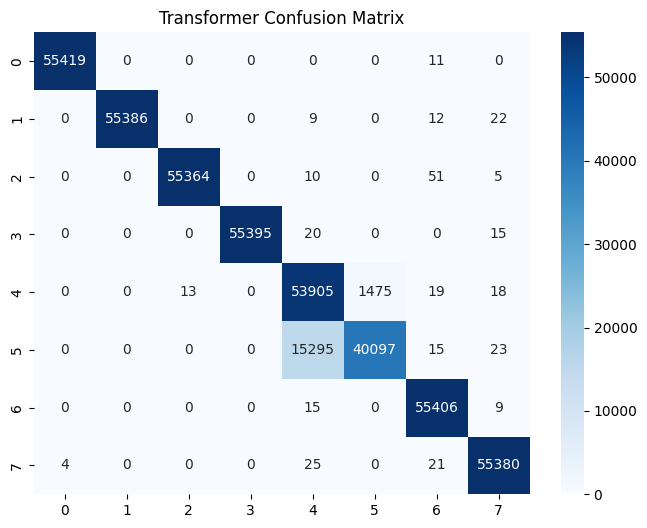

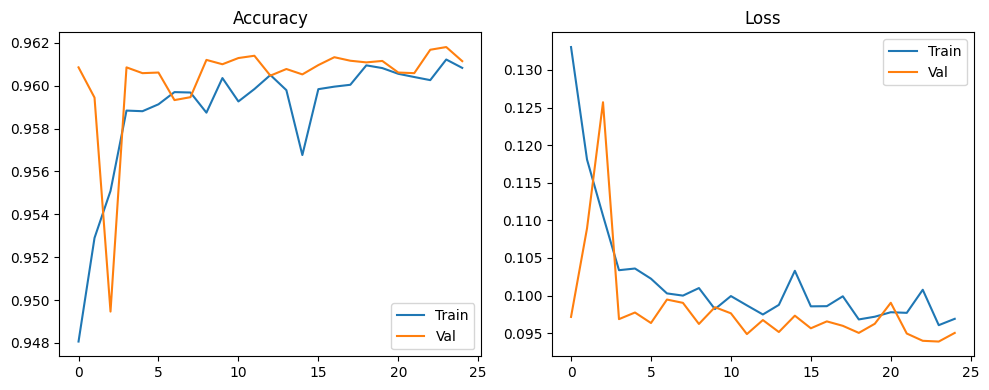

In [ ]:
# =============================================================================
# End-to-end Transformer (Encoder) training & evaluation
# =============================================================================

import os, time, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# ---------- USER SETTINGS ----------
BASE = "/content"   # ✅ FIXED

X_TRAIN_F = os.path.join(BASE, "X_train_sel_sho_multi.npy")
X_TEST_F  = os.path.join(BASE, "X_test_sel_sho_multi.npy")
Y_TRAIN_F = os.path.join(BASE, "y_train_sho_multi.npy")
Y_TEST_F  = os.path.join(BASE, "y_test_sho_multi.npy")

# Transformer hyperparams
D_MODEL = 64
NUM_HEADS = 4
D_FF = 128
NUM_LAYERS = 2
DROPOUT = 0.2

# Training hyperparams
EPOCHS = 25
BATCH_SIZE = 256   # ✅ FIXED
VAL_FRAC = 0.10
LR = 1e-3

USE_RECONSTRUCTION = False
RECON_WEIGHT = 0.3

OUT_DIR = os.path.join(BASE, "transformer_sho_multi")
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- File checks ----------
for p in [X_TRAIN_F, X_TEST_F, Y_TRAIN_F, Y_TEST_F]:
    if not Path(p).exists():
        raise FileNotFoundError(f"Required file not found: {p}")

# ---------- Load data ----------
X_train = np.load(X_TRAIN_F)
X_test  = np.load(X_TEST_F)
y_train = np.load(Y_TRAIN_F)
y_test  = np.load(Y_TEST_F)

print("Loaded shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# ---------- Scaling ----------
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ✅ Dataset stability fix
X_train_s = np.nan_to_num(X_train_s)
X_test_s  = np.nan_to_num(X_test_s)

num_classes = len(np.unique(y_train))
print("Num classes:", num_classes)

# ---------- Split ----------
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=SEED)
train_idx, val_idx = next(sss.split(X_train_s, y_train))
X_tr, X_val = X_train_s[train_idx], X_train_s[val_idx]
y_tr, y_val = y_train[train_idx], y_train[val_idx]

y_tr_oh = tf.keras.utils.to_categorical(y_tr, num_classes=num_classes)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

# ---------- MODEL ----------
from tensorflow.keras import layers
from tensorflow.keras.layers import MultiHeadAttention

class LearnedPositionEmbedding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model

    def build(self, input_shape):
        self.pos_emb = self.add_weight(shape=(self.seq_len, self.d_model),
                                       initializer="random_normal",
                                       trainable=True)
        super().build(input_shape)

    def call(self, x):
        return x + self.pos_emb[None, :, :]

def transformer_encoder_block(x):
    attn = MultiHeadAttention(num_heads=NUM_HEADS, key_dim=D_MODEL//NUM_HEADS)(x, x)
    x = layers.LayerNormalization()(x + attn)

    ffn = layers.Dense(D_FF, activation="relu")(x)
    ffn = layers.Dense(D_MODEL)(ffn)
    x = layers.LayerNormalization()(x + ffn)

    return x

def build_transformer(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim,1))(inp)
    x = layers.TimeDistributed(layers.Dense(D_MODEL))(x)

    x = LearnedPositionEmbedding(input_dim, D_MODEL)(x)

    for _ in range(NUM_LAYERS):
        x = transformer_encoder_block(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inp, out)

model = build_transformer(X_train_s.shape[1])

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ---------- TRAIN ----------
history = model.fit(
    X_tr, y_tr_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# ---------- EVALUATE (UPDATED — ALL 7 METRICS) ----------
y_pred_probs = model.predict(X_test_s)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# -------------------------------
# Basic Metrics
# -------------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')

# -------------------------------
# NEW METRICS ADDED
# -------------------------------
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize

# ROC-AUC (multi-class)
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
roc_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')

# Confusion Matrix (for FAR)
cm = confusion_matrix(y_true, y_pred)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

FAR = np.mean(FP / (FP + TN))

# MCC
mcc = matthews_corrcoef(y_true, y_pred)

# -------------------------------
# PRINT ALL METRICS
# -------------------------------
print("\n--- FINAL RESULTS (Transformer) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"FAR      : {FAR:.4f}")
print(f"MCC      : {mcc:.4f}")

# ---------- CONFUSION MATRIX ----------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Transformer Confusion Matrix")
plt.show()

# ---------- TRAINING CURVES ----------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.8932 - loss: 0.1946 - val_accuracy: 0.9056 - val_loss: 0.1452
Epoch 2/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9260 - loss: 0.1427 - val_accuracy: 0.9000 - val_loss: 0.1408
Epoch 3/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9446 - loss: 0.1212 - val_accuracy: 0.9001 - val_loss: 0.1583
Epoch 4/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9488 - loss: 0.1161 - val_accuracy: 0.9442 - val_loss: 0.1164
Epoch 5/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9527 - loss: 0.1101 - val_accuracy: 0.9571 - val_loss: 0.1015
Epoch 6/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9523 - loss: 0.1103 - val_accuracy: 0.9535 - val_loss: 0.1102
Epoch 7/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - accuracy: 0.9534 - loss: 0.1086 - val_accuracy: 0.9489 - val_loss: 0.1177
Epoch 8/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9512 - loss: 0

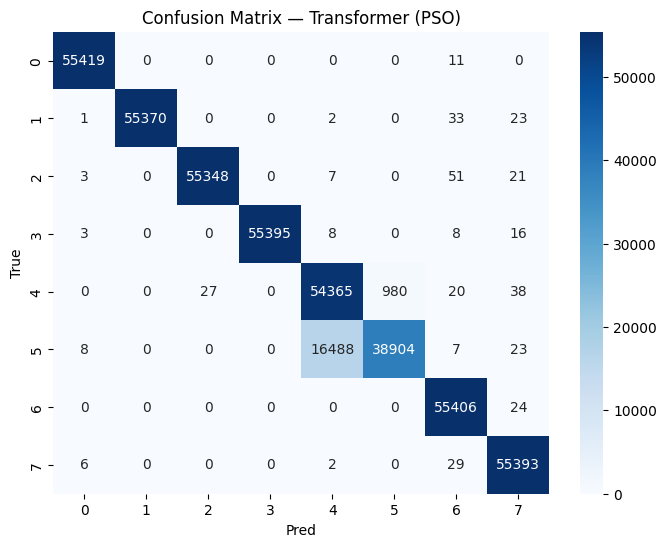

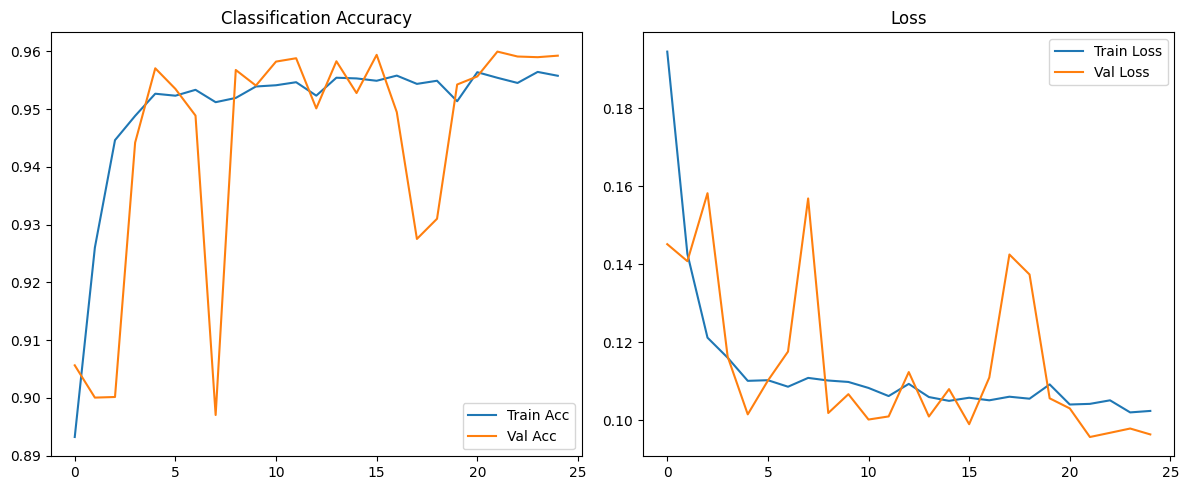

In [31]:
# Transformer_from_PSO_files.py

import os, time, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# ---------- USER PATHS (PSO outputs) ----------
BASE = "/content"   # ✅ FIXED

X_TRAIN_F = os.path.join(BASE, "X_train_sel_pso_multi.npy")
X_TEST_F  = os.path.join(BASE, "X_test_sel_pso_multi.npy")
SEL_IDX_F = os.path.join(BASE, "selected_idx_pso_multi.npy")
Y_TRAIN_F = os.path.join(BASE, "y_train_pso_multi.npy")
Y_TEST_F  = os.path.join(BASE, "y_test_pso_multi.npy")

# ---------- Model & training hyperparams ----------
D_MODEL = 64
NUM_HEADS = 4
D_FF = 128
NUM_LAYERS = 2
DROPOUT = 0.2

EPOCHS = 25
BATCH_SIZE = 256   # ✅ FIXED
VAL_FRAC = 0.10
LR = 1e-3

USE_RECONSTRUCTION = False
RECON_WEIGHT = 0.3

OUT_DIR = os.path.join(BASE, "transformer_pso_multi")
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Load data ----------
X_train = np.load(X_TRAIN_F)
X_test  = np.load(X_TEST_F)
y_train = np.load(Y_TRAIN_F)
y_test  = np.load(Y_TEST_F)

# ---------- Scale ----------
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ✅ stability fix
X_train_s = np.nan_to_num(X_train_s)
X_test_s  = np.nan_to_num(X_test_s)

# ---------- Split ----------
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=SEED)
train_idx, val_idx = next(sss.split(X_train_s, y_train))
X_tr, X_val = X_train_s[train_idx], X_train_s[val_idx]
y_tr, y_val = y_train[train_idx], y_train[val_idx]

num_classes = len(np.unique(y_train))
y_tr_oh = tf.keras.utils.to_categorical(y_tr, num_classes=num_classes)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)

# ---------- MODEL ----------
from tensorflow.keras import layers
from tensorflow.keras.layers import MultiHeadAttention

class LearnedPositionEmbedding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model

    def build(self, input_shape):
        self.pos_emb = self.add_weight(shape=(self.seq_len, self.d_model),
                                       initializer="random_normal",
                                       trainable=True)
        super().build(input_shape)

    def call(self, x):
        return x + self.pos_emb[None, :, :]

def transformer_encoder_block(x):
    attn = MultiHeadAttention(num_heads=NUM_HEADS, key_dim=D_MODEL//NUM_HEADS)(x, x)
    x = layers.LayerNormalization()(x + attn)

    ffn = layers.Dense(D_FF, activation="relu")(x)
    ffn = layers.Dense(D_MODEL)(ffn)
    x = layers.LayerNormalization()(x + ffn)

    return x

def build_transformer(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim,1))(inp)
    x = layers.TimeDistributed(layers.Dense(D_MODEL))(x)

    x = LearnedPositionEmbedding(input_dim, D_MODEL)(x)

    for _ in range(NUM_LAYERS):
        x = transformer_encoder_block(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inp, out)

model = build_transformer(X_train_s.shape[1])

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------- TRAIN ----------
history = model.fit(
    X_tr, y_tr_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# ---------- EVALUATE (UPDATED — ALL 7 METRICS) ----------
y_pred_probs = model.predict(X_test_s)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# -------------------------------
# Basic Metrics
# -------------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')

# -------------------------------
# NEW METRICS ADDED
# -------------------------------
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize

# ROC-AUC (multi-class)
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
roc_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')

# Confusion Matrix (for FAR)
cm = confusion_matrix(y_true, y_pred)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

FAR = np.mean(FP / (FP + TN))

# MCC
mcc = matthews_corrcoef(y_true, y_pred)

# -------------------------------
# PRINT ALL METRICS
# -------------------------------
print("\n--- FINAL RESULTS (Transformer - PSO) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"FAR      : {FAR:.4f}")
print(f"MCC      : {mcc:.4f}")

# ---------- CONFUSION MATRIX ----------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Transformer (PSO)")
plt.xlabel("Pred")
plt.ylabel("True")
plt.show()

# ---------- TRAINING CURVES ----------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Classification Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 55s 8ms/step - accuracy: 0.9272 - loss: 0.1550 - val_accuracy: 0.9606 - val_loss: 0.1146
Epoch 2/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9461 - loss: 0.1184 - val_accuracy: 0.9580 - val_loss: 0.1124
Epoch 3/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.9459 - loss: 0.1193 - val_accuracy: 0.9581 - val_loss: 0.1000
Epoch 4/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.9508 - loss: 0.1117 - val_accuracy: 0.9509 - val_loss: 0.1096
Epoch 5/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9513 - loss: 0.1107 - val_accuracy: 0.9142 - val_loss: 0.1174
Epoch 6/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.9511 - loss: 0.1111 - val_accuracy: 0.9447 - val_loss: 0.1268
Epoch 7/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9456 - loss: 0.1176 - val_accuracy: 0.9410 - val_loss: 0.1205
Epoch 8/25
3638/3638 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.9540 - loss: 0

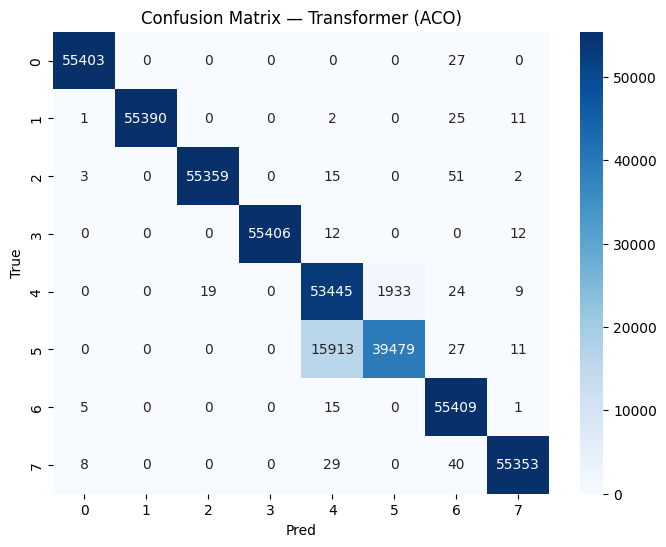

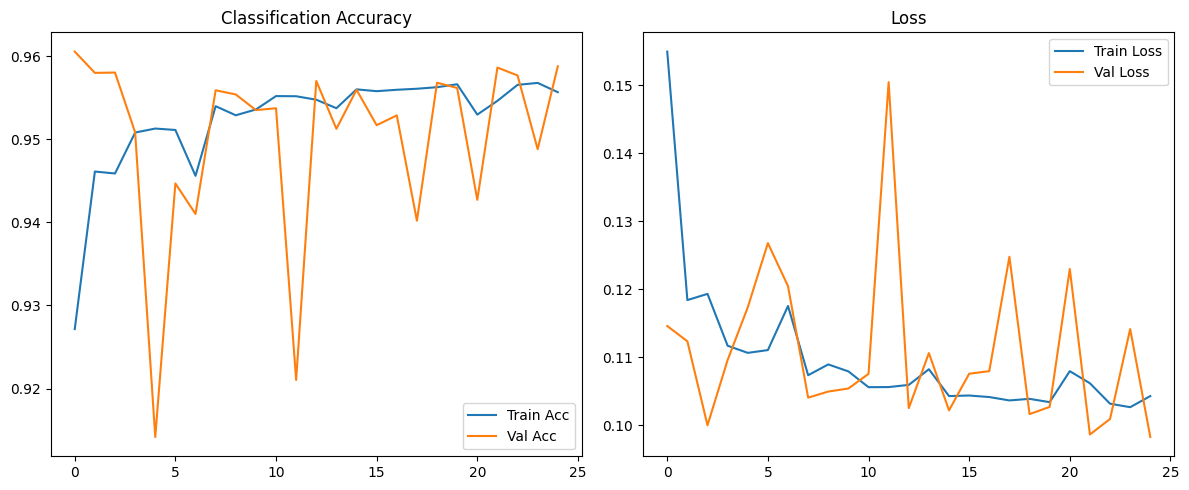

In [32]:
# Transformer_for_ACO_selected_files.py

import os, time, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# -------------------- FILE PATHS --------------------
BASE = "/content"   # ✅ FIXED

TRAIN_PATH   = os.path.join(BASE, "X_train_sel_aco_multi.npy")
TEST_PATH    = os.path.join(BASE, "X_test_sel_aco_multi.npy")
Y_TRAIN_PATH = os.path.join(BASE, "y_train_aco_multi.npy")
Y_TEST_PATH  = os.path.join(BASE, "y_test_aco_multi.npy")

# -------------------- Hyperparameters --------------------
D_MODEL = 64
NUM_HEADS = 4
D_FF = 128
NUM_LAYERS = 2
DROPOUT = 0.2

EPOCHS = 25
BATCH_SIZE = 256   # ✅ FIXED
VAL_FRAC = 0.10
LR = 1e-3

USE_RECONSTRUCTION = False
RECON_WEIGHT = 0.3

OUT_DIR = os.path.join(BASE, "transformer_aco_multi")
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------- Load data --------------------
X_train = np.load(TRAIN_PATH)
X_test  = np.load(TEST_PATH)
y_train = np.load(Y_TRAIN_PATH)
y_test  = np.load(Y_TEST_PATH)

# -------------------- Scale inputs --------------------
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ✅ stability fix
X_train_s = np.nan_to_num(X_train_s)
X_test_s  = np.nan_to_num(X_test_s)

# -------------------- Validation split --------------------
sss = StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC, random_state=SEED)
train_idx, val_idx = next(sss.split(X_train_s, y_train))
X_tr, X_val = X_train_s[train_idx], X_train_s[val_idx]
y_tr, y_val = y_train[train_idx], y_train[val_idx]

num_classes = len(np.unique(y_train))
y_tr_oh = tf.keras.utils.to_categorical(y_tr, num_classes=num_classes)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes=num_classes)

# -------------------- MODEL --------------------
from tensorflow.keras import layers
from tensorflow.keras.layers import MultiHeadAttention

class LearnedPositionEmbedding(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model

    def build(self, input_shape):
        self.pos_emb = self.add_weight(shape=(self.seq_len, self.d_model),
                                       initializer="random_normal",
                                       trainable=True)
        super().build(input_shape)

    def call(self, x):
        return x + self.pos_emb[None, :, :]

def transformer_encoder_block(x):
    attn = MultiHeadAttention(num_heads=NUM_HEADS, key_dim=D_MODEL//NUM_HEADS)(x, x)
    x = layers.LayerNormalization()(x + attn)

    ffn = layers.Dense(D_FF, activation="relu")(x)
    ffn = layers.Dense(D_MODEL)(ffn)
    x = layers.LayerNormalization()(x + ffn)

    return x

def build_transformer(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Reshape((input_dim,1))(inp)
    x = layers.TimeDistributed(layers.Dense(D_MODEL))(x)

    x = LearnedPositionEmbedding(input_dim, D_MODEL)(x)

    for _ in range(NUM_LAYERS):
        x = transformer_encoder_block(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inp, out)

model = build_transformer(X_train_s.shape[1])

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------- TRAIN --------------------
history = model.fit(
    X_tr, y_tr_oh,
    validation_data=(X_val, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# -------------------- EVALUATE (UPDATED — ALL 7 METRICS) --------------------
y_pred_probs = model.predict(X_test_s)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# -------------------------------
# Basic Metrics
# -------------------------------
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')

# -------------------------------
# NEW METRICS ADDED
# -------------------------------
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize

# ROC-AUC (multi-class)
y_true_bin = label_binarize(y_true, classes=np.unique(y_true))
roc_auc = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')

# Confusion Matrix (for FAR)
cm = confusion_matrix(y_true, y_pred)

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

FAR = np.mean(FP / (FP + TN))

# MCC
mcc = matthews_corrcoef(y_true, y_pred)

# -------------------------------
# PRINT ALL METRICS
# -------------------------------
print("\n--- FINAL RESULTS (Transformer - ACO) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"FAR      : {FAR:.4f}")
print(f"MCC      : {mcc:.4f}")

# -------------------- CONFUSION MATRIX --------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Transformer (ACO)")
plt.xlabel("Pred")
plt.ylabel("True")
plt.show()

# -------------------- TRAINING CURVES --------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Classification Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()